In [1]:
!pip install tensorflow
!pip install kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"shreyashjain04","key":"0c29b479f99a8b1cb2dfc9891aa26702"}'}

In [3]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d iarunava/cell-images-for-detecting-malaria

Dataset URL: https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria
License(s): unknown
 90% 607M/675M [00:03<00:01, 53.9MB/s]
100% 675M/675M [00:03<00:00, 193MB/s] 


In [5]:
!unzip cell-images-for-detecting-malaria.zip

Streaming output truncated to the last 5000 lines.
  inflating: cell_images/cell_images/Uninfected/C236ThinF_IMG_20151127_102428_cell_116.png  
  inflating: cell_images/cell_images/Uninfected/C236ThinF_IMG_20151127_102428_cell_118.png  
  inflating: cell_images/cell_images/Uninfected/C236ThinF_IMG_20151127_102428_cell_126.png  
  inflating: cell_images/cell_images/Uninfected/C236ThinF_IMG_20151127_102428_cell_134.png  
  inflating: cell_images/cell_images/Uninfected/C236ThinF_IMG_20151127_102428_cell_141.png  
  inflating: cell_images/cell_images/Uninfected/C236ThinF_IMG_20151127_102428_cell_168.png  
  inflating: cell_images/cell_images/Uninfected/C236ThinF_IMG_20151127_102428_cell_175.png  
  inflating: cell_images/cell_images/Uninfected/C236ThinF_IMG_20151127_102428_cell_183.png  
  inflating: cell_images/cell_images/Uninfected/C236ThinF_IMG_20151127_102428_cell_221.png  
  inflating: cell_images/cell_images/Uninfected/C236ThinF_IMG_20151127_102428_cell_222.png  
  inflating: cell_i

In [6]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

In [7]:
data_dir = "/content/cell_images"

img_size = 128
batch_size = 32

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_size,img_size),
    batch_size=batch_size
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_size,img_size),
    batch_size=batch_size
)

Found 55116 files belonging to 3 classes.
Using 44093 files for training.
Found 55116 files belonging to 3 classes.
Using 11023 files for validation.


In [8]:
model = tf.keras.Sequential([

tf.keras.layers.Rescaling(1./255),

tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
tf.keras.layers.MaxPooling2D(),

tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
tf.keras.layers.MaxPooling2D(),

tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
tf.keras.layers.MaxPooling2D(),

tf.keras.layers.Flatten(),

tf.keras.layers.Dense(128,activation='relu'),

tf.keras.layers.Dense(1,activation='sigmoid')

])

In [9]:
model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

In [10]:
history = model.fit(
train_dataset,
validation_data=val_dataset,
epochs=5
)

Epoch 1/5
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.2492 - loss: -5972220182528.0000 - val_accuracy: 0.2479 - val_loss: -195215725953024.0000
Epoch 2/5
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 38s 27ms/step - accuracy: 0.2491 - loss: -732186495942656.0000 - val_accuracy: 0.2479 - val_loss: -4181512513650688.0000
Epoch 3/5
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.2494 - loss: -7557647255470080.0000 - val_accuracy: 0.2479 - val_loss: -21547707042627584.0000
Epoch 4/5
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 38s 27ms/step - accuracy: 0.2492 - loss: -31352406562308096.0000 - val_accuracy: 0.2479 - val_loss: -65368478827151360.0000
Epoch 5/5
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 38s 28ms/step - accuracy: 0.2499 - loss: -86919684120641536.0000 - val_accuracy: 0.2479 - val_loss: -153951797055062016.0000


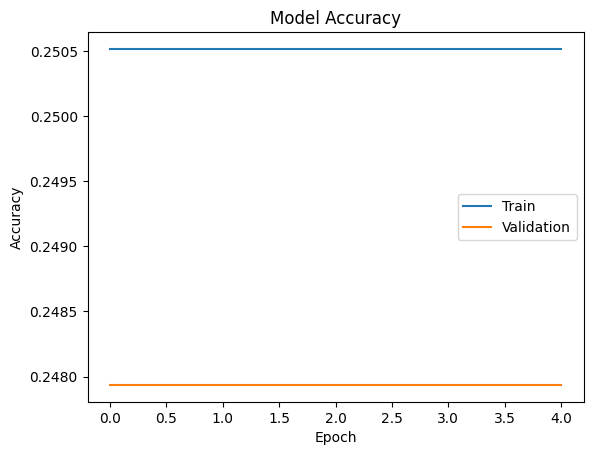

In [11]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

In [12]:
model.save("malaria_model.h5")

In [14]:
from google.colab import files
files.download("malaria_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>